In [76]:
import pandas as pd
import matplotlib.pyplot as plt

In [77]:
df = pd.read_excel('dados_cerveja_nota.xlsx')

In [78]:
df.head(5)

,id,cerveja,nota
0,1,1,0.75
1,2,1,3.00
2,3,2,1.75
3,4,3,1.75
4,5,4,4.20


In [79]:
X = df[['cerveja']] #Aqui, criamos uma matriz (Dataframe) com uma coluna só (Matriz bidimensional), pois os modelos sempre esperam receber
#uma matriz
y = df['nota'] #Já aqui, passamos um vetor (Series), já que sempre temos só um target

In [80]:
print(X.head(5))
print(X.shape)

   cerveja
0        1
1        1
2        2
3        3
4        4
(15, 1)


In [81]:
y

,nota
0,0.75
1,3.00
2,1.75
3,1.75
4,4.20
5,6.50
6,2.90
7,6.20
8,7.00
9,6.20


#**Regressão linear x Regressão com Árvore de Decisão**

In [82]:
from sklearn import tree
from sklearn import linear_model

In [83]:
reg_linear = linear_model.LinearRegression(fit_intercept=True) #Quando fazemos uma regressão linear, podemos usar o parametro fit_intercept (ou o a (lugar onde
# a reta está alocada) da fórmula de regressão linear)

full_tree = tree.DecisionTreeRegressor(random_state=42)

depth2_tree = tree.DecisionTreeRegressor(random_state=42, max_depth=2)

In [84]:
reg_linear.fit(X,y)
full_tree.fit(X,y)
depth2_tree.fit(X,y)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [85]:
#Coeficiente e intercepto da regressão linear
a, b = reg_linear.intercept_, reg_linear.coef_[0]
print(f"Coeficiente: {b:.3f}")
print(f"Intercepto: {a:.3f}")

Coeficiente: 1.036
Intercepto: 0.152


In [86]:
predict = reg_linear.predict(X.drop_duplicates()) #Aqui, fazemos predições em cima dos nossos dados (dropamos duplicados para fins de orga-
#nização)

predict_full_tree = full_tree.predict(X.drop_duplicates())

predict_depth2_tree = depth2_tree.predict(X.drop_duplicates())

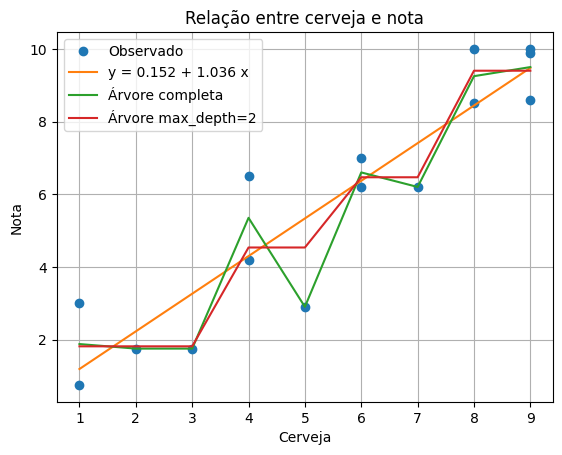

In [90]:
#Criando o gráfico
plt.plot(X['cerveja'], y,'o') #ponto de interseção de x e y, escolho tipo 'o' para usar as bolinhas
plt.grid(True)
plt.title("Relação entre cerveja e nota")
plt.xlabel("Cerveja")
plt.ylabel("Nota")
plt.plot(X.drop_duplicates()['cerveja'], predict, '-') #Agora ploto a predição para cada um desses pontos. Meu são os valores únicos das cervejas,
#e meu y é a predição para cada um deles (o que já fizemos lá encima e passamos só a variável no plot)

plt.plot(X.drop_duplicates()['cerveja'], predict_full_tree )

plt.plot(X.drop_duplicates()['cerveja'], predict_depth2_tree)

plt.legend(['Observado',
            f'y = {a:.3f} + {b:.3f} x',
            'Árvore completa',
            'Árvore max_depth=2']) #legenda para cada um dos plots

Nesse caso, ao usarmos a árvore completa para o treinamento de dados, geramos um overfit. Isso é observado pois nosso modelo não tem a capacidade de generalizar, e para todos os pontos que só existe uma cerveja, ele prediz exatamente a cerveja. Isso também pode ser observado pela abruptez que a predição muda de um ponto pro outro. A arvore de decisão do sickit-learn por padrão, tenta dividir os dados até que chegue em um nó inseparável (nó com sample=1, ou nó com sample=2 que não pode mais ser separado, como o caso de valores de cerveja com 2 individuos).

Depois disso, vemos a predição do mesmo modelo de arvore de decisão regressora, mas com o ajuste de hiperparametro. Configuramos o critério de parada com max_depth=2 (4 nós, e 1 média para cada nó). Com isso, o modelo consegue generalizar mais.

Para uma árvore simétrica, o parametro max_depth informa a quantidade de nós máximo. Com isso,conseguimos saber a quantidade de médias que eu tenho a cada nó da árvore, sendo:
2^n (n = nó atual da árvore de decisão).
Para sabermos a quantidade final de nós, simplesmente: 2^n , sendo n o número de nós do max_depth.

Outros critérios de parada:
1. min_samples_leaf, o qual faz o modelo parar de dividir assim que os nós debaixo tiverem n de amostra. Isso serve para preservar a representatividade estátistica em alguns casos, evitando que a árvore divida e crie nós com somente 2 de amostra por exemplo.

2. min_samples_split: Só divide o nó atual caso ele tenha n de amostra

3. max_leaf_nodes: Nùmero máximo de nós da árvore

4. min_impurity_decrease: minimo de impureza. O modelo sempre busca o minimo de impureza por padrão. Usar esse parametro faz com que o modelo pare de dividir assim que n nivel de pureza seja atingido.

#**Plotando árvore de decisão regressora**

[Text(0.5, 0.8333333333333334, 'cerveja <= 5.5\nsquared_error = 9.772\nsamples = 15\nvalue = 5.817'),
 Text(0.25, 0.5, 'cerveja <= 3.5\nsquared_error = 3.126\nsamples = 7\nvalue = 2.979'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.637\nsamples = 4\nvalue = 1.812'),
 Text(0.375, 0.16666666666666666, 'squared_error = 2.216\nsamples = 3\nvalue = 4.533'),
 Text(0.75, 0.5, 'cerveja <= 7.5\nsquared_error = 2.372\nsamples = 8\nvalue = 8.3'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.142\nsamples = 3\nvalue = 6.467'),
 Text(0.875, 0.16666666666666666, 'squared_error = 0.484\nsamples = 5\nvalue = 9.4')]

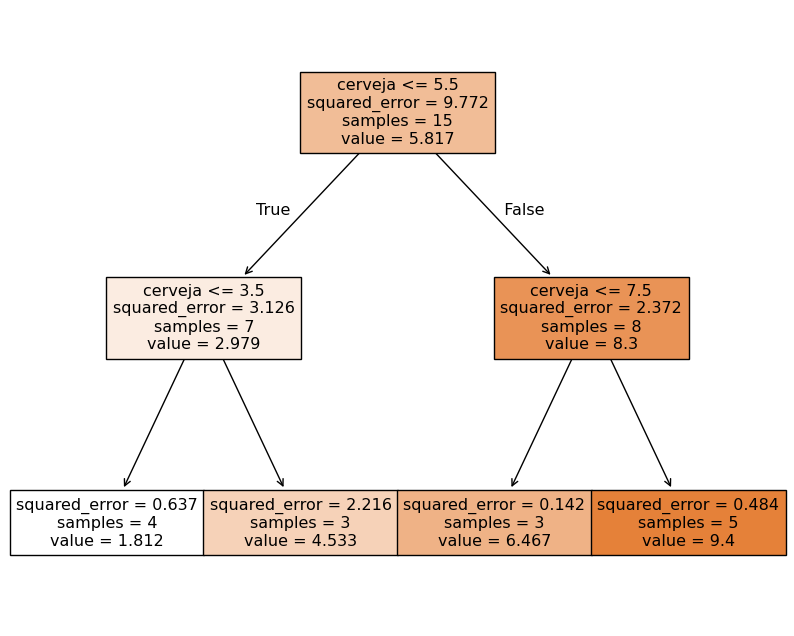

In [94]:
plt.figure(figsize=(10,8), dpi=100)
tree.plot_tree(depth2_tree, feature_names=['cerveja'], filled=True)

No primeiro nó da árvore, podemos ver que o erro quadrático é 9.77, temos 15 observações, e que a média atribuída para todo mundo é 5.8.

Quando olhamos o primeiro fatiamento da árvore, percebemos como o erro quadrático cai bastante nos dois grupos, e as médias  se afastam bastante pois em um grupo está quem bebe mais e o outro quem bebe menos.

No último fatiamento (4 grupos), o erro quadrático fica mais baixo ainda, e as médias se mostram maiores conforme mais cervejas, demonstrando uma relação positiva.